In [ ]:
# Load required data directly from local SQLite database
from pathlib import Path
import sqlite3
import pandas as pd

base_data = Path('../data')
db_path = base_data / 'processed' / 'neuro_genomic.db'
db_path.parent.mkdir(parents=True, exist_ok=True)

# Auto-bootstrap DB from local CSV once if database does not exist
if not db_path.exists():
    physio_csv = pd.read_csv(base_data / 'physio' / 'sample_physio.csv')
    genomic_csv = pd.read_csv(base_data / 'genomic' / 'sample_genomic.csv')
    behavioral_csv = pd.read_csv(base_data / 'behavioral' / 'sample_behavioral.csv')

    for df in (physio_csv, genomic_csv, behavioral_csv):
        obj_cols = df.select_dtypes(include='object').columns
        for col in obj_cols:
            df[col] = df[col].astype(str).str.strip()

    with sqlite3.connect(db_path) as conn:
        physio_csv.to_sql('physio_data', conn, if_exists='replace', index=False)
        genomic_csv.to_sql('genomic_data', conn, if_exists='replace', index=False)
        behavioral_csv.to_sql('behavioral_data', conn, if_exists='replace', index=False)

# Direct database import
with sqlite3.connect(db_path) as conn:
    physio_data = pd.read_sql_query('SELECT * FROM physio_data', conn)
    genomic_data = pd.read_sql_query('SELECT * FROM genomic_data', conn)
    behavioral_data = pd.read_sql_query('SELECT * FROM behavioral_data', conn)

print('Loaded from database:')
print(f'  physio: {physio_data.shape}')
print(f'  genomic: {genomic_data.shape}')
print(f'  behavioral: {behavioral_data.shape}')
physio_data.head()

Loaded from database:
  physio: (650000, 7)
  genomic: (650, 5)
  behavioral: (650, 5)


,sample_index,time_sec,MLII,V5,record_name,database,sampling_rate
0,0,0.000000,-0.145,-0.065,100,mitdb,360.0
1,1,0.002778,-0.145,-0.065,100,mitdb,360.0
2,2,0.005556,-0.145,-0.065,100,mitdb,360.0
3,3,0.008333,-0.145,-0.065,100,mitdb,360.0
4,4,0.011111,-0.145,-0.065,100,mitdb,360.0


In [8]:
# Physio variable setup and validation
# This cell guarantees physio_data exists and defines feature columns based on schema.
if 'physio_data' not in globals():
    from pathlib import Path
    import sqlite3
    import pandas as pd

    db_path = Path('../data/processed/neuro_genomic.db')
    if not db_path.exists():
        raise FileNotFoundError(f'Database not found at {db_path}. Run Cell 1 first.')

    with sqlite3.connect(db_path) as conn:
        physio_data = pd.read_sql_query('SELECT * FROM physio_data', conn)

# Preferred columns for old synthetic schema
legacy_cols = ['heart_rate', 'eda', 'respiration', 'eeg_alpha', 'mouse_speed']
legacy_available = [c for c in legacy_cols if c in physio_data.columns]

if legacy_available:
    physio_feature_cols = legacy_available
else:
    # MIT-BIH schema fallback: use numeric ECG channels
    excluded = {'sample_index', 'time_sec', 'sampling_rate'}
    physio_feature_cols = [
        c for c in physio_data.columns
        if c not in excluded and pd.api.types.is_numeric_dtype(physio_data[c])
    ]

if not physio_feature_cols:
    raise ValueError('No usable physiological feature columns were found in physio_data.')

print(f'physio_data shape: {physio_data.shape}')
print('physio_data columns:', list(physio_data.columns))
print('physio_feature_cols:', physio_feature_cols)
physio_data.head(3)

physio_data shape: (650000, 7)
physio_data columns: ['sample_index', 'time_sec', 'MLII', 'V5', 'record_name', 'database', 'sampling_rate']
physio_feature_cols: ['MLII', 'V5']


,sample_index,time_sec,MLII,V5,record_name,database,sampling_rate
0,0,0.000000,-0.145,-0.065,100,mitdb,360.0
1,1,0.002778,-0.145,-0.065,100,mitdb,360.0
2,2,0.005556,-0.145,-0.065,100,mitdb,360.0


In [9]:
# Define and validate physiological feature columns used in analysis cells
if 'physio_data' not in globals():
    from pathlib import Path
    import sqlite3
    import pandas as pd

    db_path = Path('../data/processed/neuro_genomic.db')
    if not db_path.exists():
        raise FileNotFoundError(f'Database not found at {db_path}. Run Cell 1 first.')

    with sqlite3.connect(db_path) as conn:
        physio_data = pd.read_sql_query('SELECT * FROM physio_data', conn)

if 'physio_feature_cols' not in globals() or not physio_feature_cols:
    legacy_cols = ['heart_rate', 'eda', 'respiration', 'eeg_alpha', 'mouse_speed']
    legacy_available = [c for c in legacy_cols if c in physio_data.columns]
    if legacy_available:
        physio_feature_cols = legacy_available
    else:
        excluded = {'sample_index', 'time_sec', 'sampling_rate'}
        physio_feature_cols = [
            c for c in physio_data.columns
            if c not in excluded and pd.api.types.is_numeric_dtype(physio_data[c])
        ]

if not physio_feature_cols:
    raise ValueError('No usable physiological feature columns found for analysis.')

print('physio_data variable is ready.')
print('Available columns:', list(physio_data.columns))
print('Analysis feature columns:', physio_feature_cols)
print('Shape:', physio_data.shape)

physio_data variable is ready.
Available columns: ['sample_index', 'time_sec', 'MLII', 'V5', 'record_name', 'database', 'sampling_rate']
Analysis feature columns: ['MLII', 'V5']
Shape: (650000, 7)


       MLII     V5
MLII  1.000  0.603
V5    0.603  1.000


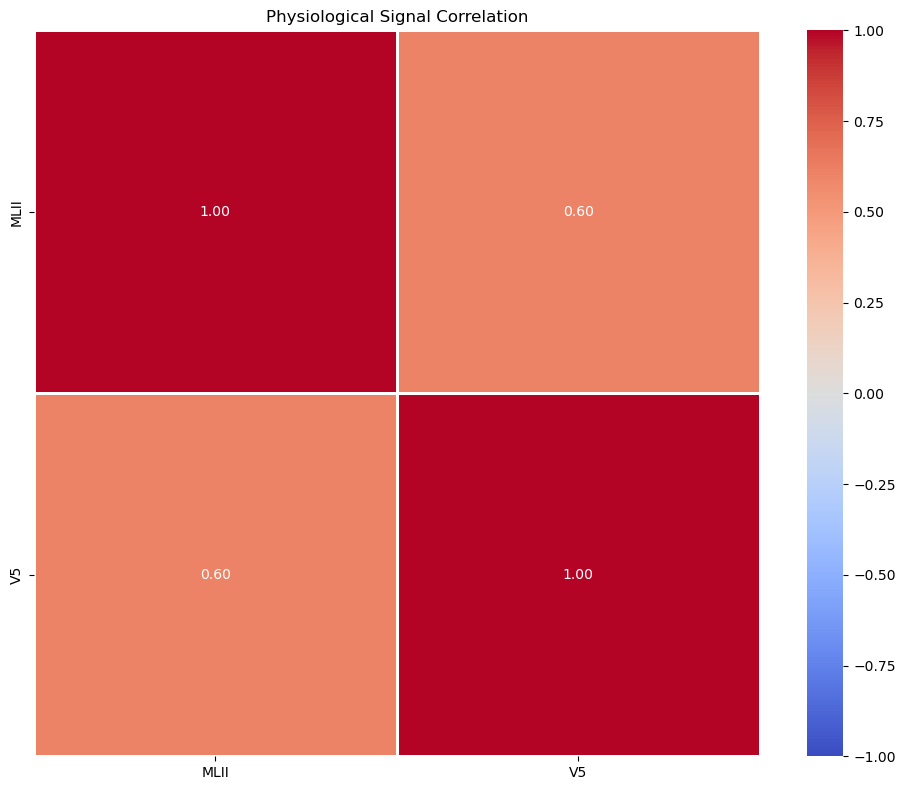

In [14]:
# Correlation analysis
# Auto-load DB tables if this cell is run before the data-loading cell
if 'physio_data' not in globals():
    from pathlib import Path
    import sqlite3
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns

    db_path = Path('../data/processed/neuro_genomic.db')
    if not db_path.exists():
        raise FileNotFoundError(f'Database not found at {db_path}. Run Cell 1 first.')

    with sqlite3.connect(db_path) as conn:
        physio_data = pd.read_sql_query('SELECT * FROM physio_data', conn)

if 'physio_feature_cols' not in globals() or not physio_feature_cols:
    legacy_cols = ['heart_rate', 'eda', 'respiration', 'eeg_alpha', 'mouse_speed']
    legacy_available = [c for c in legacy_cols if c in physio_data.columns]
    if legacy_available:
        physio_feature_cols = legacy_available
    else:
        excluded = {'sample_index', 'time_sec', 'sampling_rate'}
        physio_feature_cols = [
            c for c in physio_data.columns
            if c not in excluded and pd.api.types.is_numeric_dtype(physio_data[c])
        ]

correlation_matrix = physio_data[physio_feature_cols].corr()
print(correlation_matrix.round(3))

plots_dir = Path('../results/plots')
plots_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1, vmin=-1, vmax=1)
plt.title('Physiological Signal Correlation')
plt.tight_layout()
plt.savefig(plots_dir / 'correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Descriptive statistics
if 'physio_data' not in globals():
    from pathlib import Path
    import sqlite3
    import pandas as pd

    db_path = Path('../data/processed/neuro_genomic.db')
    if not db_path.exists():
        raise FileNotFoundError(f'Database not found at {db_path}. Run Cell 1 first.')

    with sqlite3.connect(db_path) as conn:
        physio_data = pd.read_sql_query('SELECT * FROM physio_data', conn)

if 'physio_feature_cols' not in globals() or not physio_feature_cols:
    legacy_cols = ['heart_rate', 'eda', 'respiration', 'eeg_alpha', 'mouse_speed']
    legacy_available = [c for c in legacy_cols if c in physio_data.columns]
    if legacy_available:
        physio_feature_cols = legacy_available
    else:
        excluded = {'sample_index', 'time_sec', 'sampling_rate'}
        physio_feature_cols = [
            c for c in physio_data.columns
            if c not in excluded and pd.api.types.is_numeric_dtype(physio_data[c])
        ]

print(physio_data[physio_feature_cols].describe().round(2))

for col in physio_feature_cols:
    data = physio_data[col]
    print(f"\n{col}: skew={data.skew():.3f}  kurtosis={data.kurtosis():.3f}")

            MLII         V5
count  650000.00  650000.00
mean       -0.31      -0.19
std         0.19       0.15
min        -2.72      -2.46
25%        -0.39      -0.26
50%        -0.34      -0.20
75%        -0.27      -0.14
max         1.44       1.23

MLII: skew=4.426  kurtosis=25.413

V5: skew=2.710  kurtosis=16.165


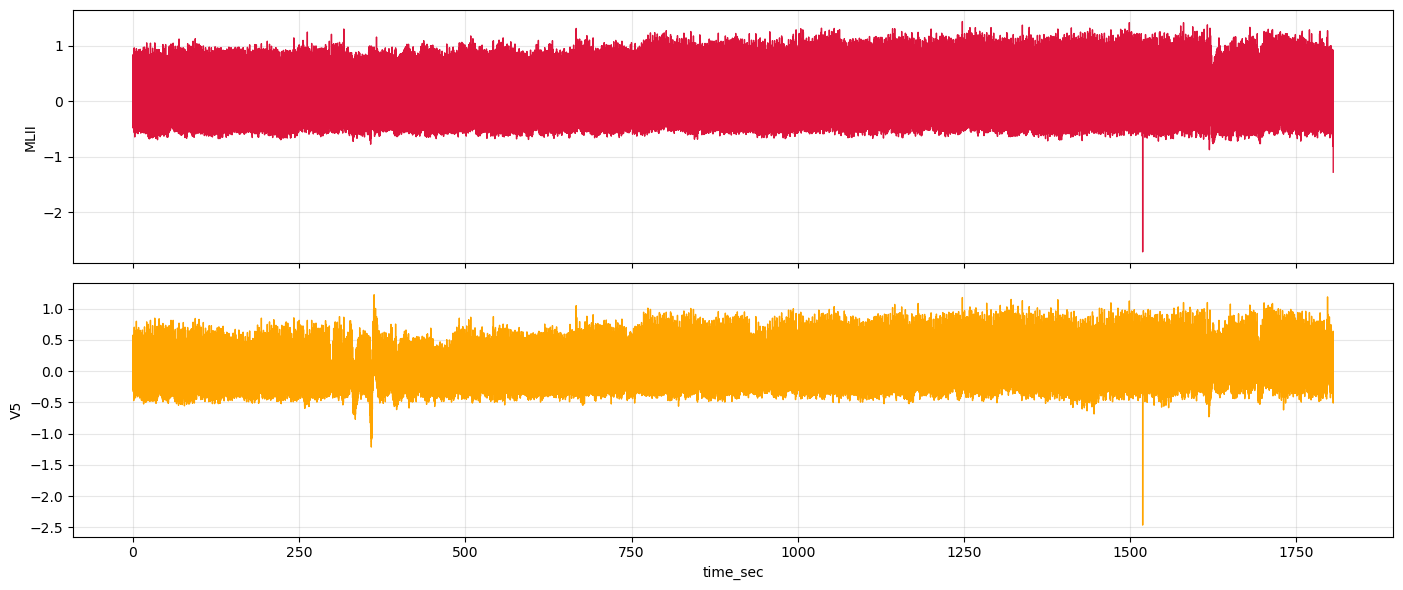

In [15]:
# Plot physiological signals
if 'physio_data' not in globals():
    from pathlib import Path
    import sqlite3
    import pandas as pd
    import matplotlib.pyplot as plt

    db_path = Path('../data/processed/neuro_genomic.db')
    if not db_path.exists():
        raise FileNotFoundError(f'Database not found at {db_path}. Run Cell 1 first.')

    with sqlite3.connect(db_path) as conn:
        physio_data = pd.read_sql_query('SELECT * FROM physio_data', conn)

if 'physio_feature_cols' not in globals() or not physio_feature_cols:
    legacy_cols = ['heart_rate', 'eda', 'respiration', 'eeg_alpha', 'mouse_speed']
    legacy_available = [c for c in legacy_cols if c in physio_data.columns]
    if legacy_available:
        physio_feature_cols = legacy_available
    else:
        excluded = {'sample_index', 'time_sec', 'sampling_rate'}
        physio_feature_cols = [
            c for c in physio_data.columns
            if c not in excluded and pd.api.types.is_numeric_dtype(physio_data[c])
        ]

x_col = 'timestamp' if 'timestamp' in physio_data.columns else ('time_sec' if 'time_sec' in physio_data.columns else 'sample_index')

fig, axes = plt.subplots(len(physio_feature_cols), 1, figsize=(14, 3 * len(physio_feature_cols)), sharex=True)
if len(physio_feature_cols) == 1:
    axes = [axes]

palette = ['crimson', 'orange', 'green', 'purple', 'blue', 'teal', 'brown', 'magenta']
for i, (ax, col) in enumerate(zip(axes, physio_feature_cols)):
    ax.plot(physio_data[x_col], physio_data[col], linewidth=1, color=palette[i % len(palette)])
    ax.set_ylabel(col)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel(x_col)

plots_dir = Path('../results/plots')
plots_dir.mkdir(parents=True, exist_ok=True)

plt.tight_layout()
plt.savefig(plots_dir / 'physiological_signals.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# Quick preview of loaded database tables
if not {'physio_data', 'genomic_data', 'behavioral_data'}.issubset(globals()):
    from pathlib import Path
    import sqlite3
    import pandas as pd

    db_path = Path('../data/processed/neuro_genomic.db')
    if not db_path.exists():
        raise FileNotFoundError(f'Database not found at {db_path}. Run Cell 1 first.')

    with sqlite3.connect(db_path) as conn:
        physio_data = pd.read_sql_query('SELECT * FROM physio_data', conn)
        genomic_data = pd.read_sql_query('SELECT * FROM genomic_data', conn)
        behavioral_data = pd.read_sql_query('SELECT * FROM behavioral_data', conn)

print('Physio columns:', list(physio_data.columns))
print('Genomic columns:', list(genomic_data.columns))
print('Behavioral columns:', list(behavioral_data.columns))

print('\nPhysio sample:')
print(physio_data.head(3))

print('\nGenomic sample:')
print(genomic_data.head(3))

print('\nBehavioral sample:')
print(behavioral_data.head(3))

Physio columns: ['sample_index', 'time_sec', 'MLII', 'V5', 'record_name', 'database', 'sampling_rate']
Genomic columns: ['sample_id', 'gene_expression_a', 'gene_expression_b', 'gene_expression_c', 'variant_load']
Behavioral columns: ['task_id', 'click_rate', 'typing_speed', 'error_rate', 'focus_score']

Physio sample:
   sample_index  time_sec   MLII     V5 record_name database  sampling_rate
0             0  0.000000 -0.145 -0.065         100    mitdb          360.0
1             1  0.002778 -0.145 -0.065         100    mitdb          360.0
2             2  0.005556 -0.145 -0.065         100    mitdb          360.0

Genomic sample:
   sample_id  gene_expression_a  gene_expression_b  gene_expression_c  \
0          0           0.674507           0.621875           0.433191   
1          1           0.579260           0.535188           0.599204   
2          2           0.697153           0.367733           0.482504   

   variant_load  
0             2  
1             2  
2           

In [17]:
# Imports for plotting style
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
print('Libraries imported.')

Libraries imported.


In [ ]:
# Verify dependencies
packages = ['numpy', 'pandas', 'sklearn', 'matplotlib', 'seaborn', 'scipy', 'plotly']
for pkg in packages:
    try:
        __import__(pkg)
        print(f'  {pkg}: installed')
    except ImportError:
        print(f'  {pkg}: MISSING')

  numpy: installed
  pandas: installed
  sklearn: installed
  matplotlib: installed
  seaborn: installed
  scipy: installed
  plotly: installed


In [ ]:
# Create project directory structure
from pathlib import Path

structure = {
    'data': ['physio', 'genomic', 'behavioral'],
    'notebooks': [],
    'src': [],
    'diagrams': [],
    'docs': [],
    'results': ['plots', 'models']
}

base_path = Path('.')
for main_dir, subdirs in structure.items():
    (base_path / main_dir).mkdir(exist_ok=True)
    for subdir in subdirs:
        (base_path / main_dir / subdir).mkdir(exist_ok=True)

print('Project structure created.')

Project structure created.
